# Shape-Based CBIR Using Hu Moments

This notebook implements a Content-Based Image Retrieval (CBIR) system
using Hu Moments shape features.

Steps:
- Load processed dataset
- Convert image to grayscale
- Extract Hu Moments features
- Build feature database
- Compare query image with dataset images
- Retrieve top similar images

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
DATASET_PATH = "processed_dataset"

categories = sorted(os.listdir(DATASET_PATH))
print("Categories:", categories)

Categories: ['ambulance', 'bicycle', 'bus', 'car', 'fire_truck', 'motorcycle', 'tractor', 'truck', 'van']


## Hu Moments Feature Extraction

Hu Moments are shape descriptors extracted from image moments.
They are useful for representing the overall structure of an object.

In [3]:
def extract_hu_moments(image_path):
    """
    Extract Hu Moments from an image.

    Parameters:
        image_path : str
            Path to input image

    Returns:
        hu_features : numpy array
            7-dimensional Hu Moments feature vector
    """
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if image is None:
        return None

    blurred = cv2.GaussianBlur(image, (5, 5), 0)

    # Otsu thresholding automatically selects a threshold value
    _, thresh = cv2.threshold(
        blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    moments = cv2.moments(thresh)
    hu = cv2.HuMoments(moments).flatten()

    hu = -np.sign(hu) * np.log10(np.abs(hu) + 1e-10)

    return hu

## Build Feature Database

For each image in the dataset:
- extract Hu Moments
- store image path
- store category label

In [4]:
image_paths = []
image_labels = []
features = []

for category in categories:
    category_path = os.path.join(DATASET_PATH, category)

    for img_name in os.listdir(category_path):
        img_path = os.path.join(category_path, img_name)
        hu_feature = extract_hu_moments(img_path)

        if hu_feature is not None:
            image_paths.append(img_path)
            image_labels.append(category)
            features.append(hu_feature)

features = np.array(features)

print("Total images indexed:", len(image_paths))
print("Feature shape:", features.shape)

Total images indexed: 1800
Feature shape: (1800, 7)


## Similarity Function

We compare the query image with all dataset images using cosine similarity.
Higher score means more similar.

In [5]:
def retrieve_similar_images(query_image_path, top_k=5):
    """
    Retrieve top_k similar images using Hu Moments shape features.
    """
    query_feature = extract_hu_moments(query_image_path)

    if query_feature is None:
        print("Query image could not be loaded.")
        return []

    similarities = cosine_similarity([query_feature], features)[0]

    # Sort from highest similarity to lowest
    sorted_indices = np.argsort(similarities)[::-1]

    results = []
    for idx in sorted_indices:
        # Skip the query image itself
        if image_paths[idx] == query_image_path:
            continue

        results.append({
            "image_path": image_paths[idx],
            "label": image_labels[idx],
            "score": similarities[idx]
        })

        if len(results) == top_k:
            break

    return results

## Test with a Query Image

A query image is selected automatically from one category folder.

In [6]:
category_path = "processed_dataset/bus"   # change category if needed
img_name = os.listdir(category_path)[1]

query_image = os.path.join(category_path, img_name)

print("Using query image:", query_image)

results = retrieve_similar_images(query_image, top_k=5)

for i, result in enumerate(results, 1):
    print(f"Rank {i}: {result['label']} | Score = {result['score']:.4f}")

Using query image: processed_dataset/bus\062697ff-7ee3-4a53-a686-5256447b2f1f.jpg
Rank 1: bus | Score = 1.0000
Rank 2: motorcycle | Score = 1.0000
Rank 3: bus | Score = 1.0000
Rank 4: fire_truck | Score = 1.0000
Rank 5: bus | Score = 0.9999


## Display Query Image and Retrieved Results

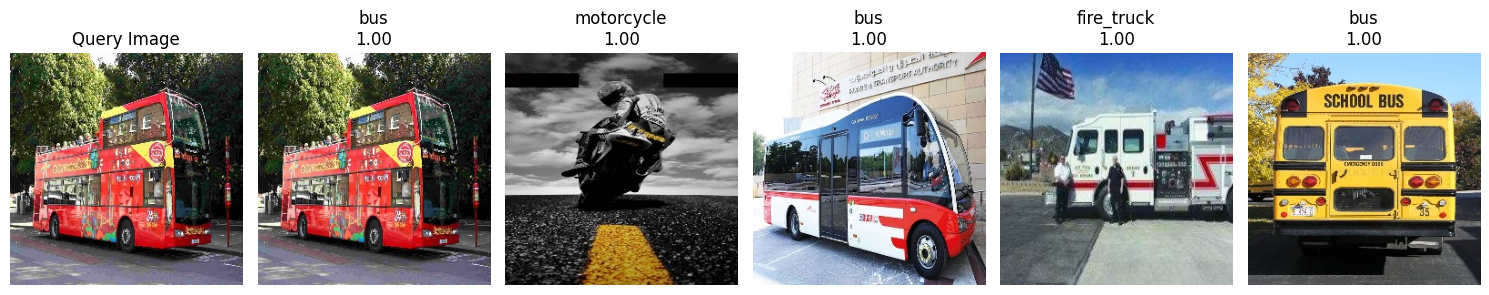

In [7]:
def display_results(query_image_path, results):
    plt.figure(figsize=(15, 4))

    # Show query image
    query_img = cv2.imread(query_image_path)
    query_img = cv2.cvtColor(query_img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, len(results) + 1, 1)
    plt.imshow(query_img)
    plt.title("Query Image")
    plt.axis("off")

    # Show retrieved images
    for i, result in enumerate(results, start=2):
        img = cv2.imread(result["image_path"])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(1, len(results) + 1, i)
        plt.imshow(img)
        plt.title(f"{result['label']}\n{result['score']:.2f}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

display_results(query_image, results)

## Precision@5 Evaluation

In [8]:
def precision_at_k(query_image_path, results, k=5):
    query_label = os.path.basename(os.path.dirname(query_image_path))
    correct = sum(1 for r in results[:k] if r["label"] == query_label)
    return correct / k

p_at_5 = precision_at_k(query_image, results, k=5)
print(f"Precision@5: {p_at_5:.2f}")

Precision@5: 0.60


## Test Another Category

Hu Moments usually work better for categories with stronger shape information.
Examples:
- processed_dataset/buses
- processed_dataset/dinosaurs
- processed_dataset/horses

Using query image: processed_dataset/fire_truck\06B53CBLVHGK.jpg


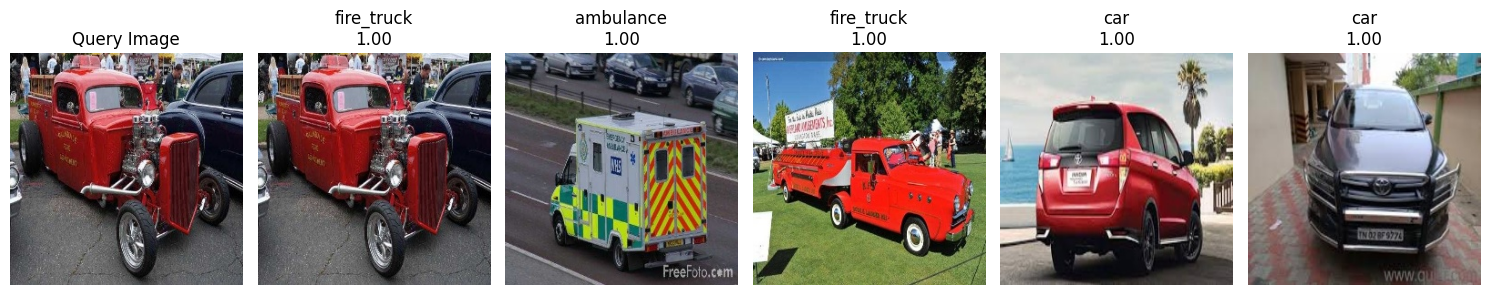

Precision@5: 0.40


In [9]:
category_path = "processed_dataset/fire_truck"
img_name = os.listdir(category_path)[0]
query_image = os.path.join(category_path, img_name)

print("Using query image:", query_image)

results = retrieve_similar_images(query_image, top_k=5)
display_results(query_image, results)

p_at_5 = precision_at_k(query_image, results, k=5)
print(f"Precision@5: {p_at_5:.2f}")

## Summary

This notebook builds a CBIR system using Hu Moments shape features.

Hu Moments are useful for retrieving images based on object structure and shape.
They are more suitable for categories where the main object has a clear form.

However, performance may decrease when the object is mixed with a complex background.